1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

2. Load and Prepare Dataset

In [11]:
df = pd.read_csv("HRDataset_v14.csv")
df['DOB'] = pd.to_datetime(df['DOB'], format='%m/%d/%y', errors='coerce')
df['DOB'] = df['DOB'].apply(lambda x: x.replace(year=x.year - 100) if x.year > 2026 else x)
df['Age'] = 2026 - df['DOB'].dt.year
df = df.dropna(subset=['Age'])
df[['Employee_Name', 'DOB', 'Age', 'GenderID', 'Salary']].head()

,Employee_Name,DOB,Age,GenderID,Salary
0,"Adinolfi, Wilson K",1983-07-10,43,1,62506
1,"Ait Sidi, Karthikeyan",1975-05-05,51,1,104437
2,"Akinkuolie, Sarah",1988-09-19,38,0,64955
3,"Alagbe,Trina",1988-09-27,38,0,64991
4,"Anderson, Carol",1989-09-08,37,0,50825


3. Data Exploration (EDA)

Shape : (311, 37)

Missing Value
Age                 0
GenderID            0
Salary              0
EngagementSurvey    0
EmpSatisfaction     0
Absences            0
dtype: int64


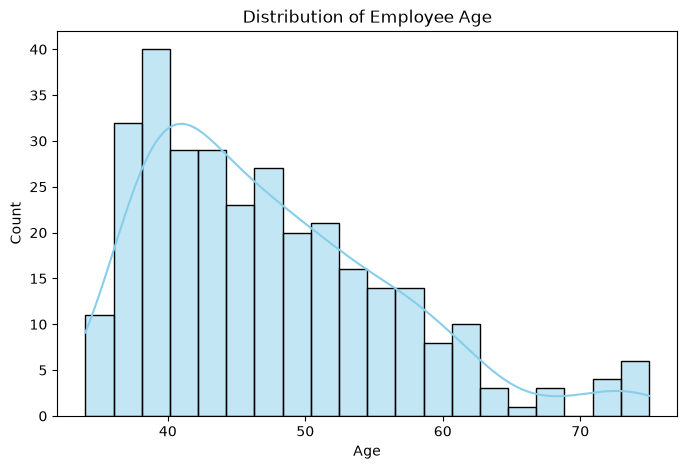

In [12]:
print("Shape :", df.shape)
print("\nMissing Value")
print(df[['Age', 'GenderID', 'Salary', 'EngagementSurvey', 'EmpSatisfaction', 'Absences']].isnull().sum())
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Employee Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

4. Simple Linear Regression

In [13]:
X_simple = df[["Salary"]]
y_reg = df["Age"]
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_reg, test_size=0.2, random_state=42
)
model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)
y_pred_simple = model_simple.predict(X_test_s)
mae_s = mean_absolute_error(y_test_s, y_pred_simple)
rmse_s = np.sqrt(mean_squared_error(y_test_s, y_pred_simple))
r2_s = r2_score(y_test_s, y_pred_simple)
print("Simple Linear Regression (Predict Age from Salary)")
print(f"MAE : {mae_s:.3f}")
print(f"RMSE : {rmse_s:.3f}")
print(f"R² : {r2_s:.3f}")

Simple Linear Regression (Predict Age from Salary)
MAE : 6.501
RMSE : 8.297
R² : 0.003


5. Multiple Linear Regression

In [14]:
features = ['Salary', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'DaysLateLast30', 'Absences']
X_multi = df[features]
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_reg, test_size=0.2, random_state=42
)
model_multiple = LinearRegression()
model_multiple.fit(X_train_m, y_train_m)
y_pred_multiple = model_multiple.predict(X_test_m)
mae_m = mean_absolute_error(y_test_m, y_pred_multiple)
rmse_m = np.sqrt(mean_squared_error(y_test_m, y_pred_multiple))
r2_m = r2_score(y_test_m, y_pred_multiple)
print("Multiple Linear Regression (Predict Age from Multiple Features)")
print(f"MAE : {mae_m:.3f}")
print(f"RMSE : {rmse_m:.3f}")
print(f"R² : {r2_m:.3f}")

Multiple Linear Regression (Predict Age from Multiple Features)
MAE : 6.631
RMSE : 8.347
R² : -0.009


6. Preparing Classification Data

In [15]:
y_clf = df["GenderID"]
X_clf = df[features]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

7. Logistic Regression Model & Evaluation

Classification Accuracy : 0.571

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.89      0.70        36
           1       0.50      0.15      0.23        27

    accuracy                           0.57        63
   macro avg       0.54      0.52      0.47        63
weighted avg       0.55      0.57      0.50        63



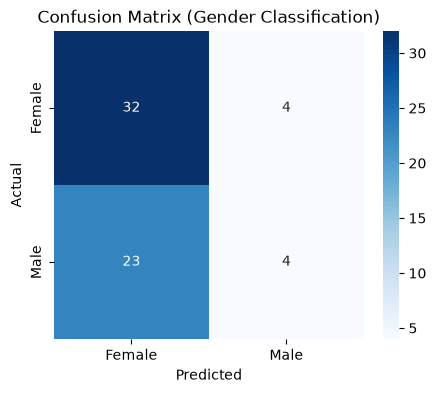

In [16]:
model_clf = LogisticRegression(random_state=42)
model_clf.fit(X_train_pca, y_train_c)
y_pred_c = model_clf.predict(X_test_pca)
acc = accuracy_score(y_test_c, y_pred_c)
print(f"Classification Accuracy : {acc:.3f}\n")
print("Classification Report:")
print(classification_report(y_test_c, y_pred_c))
cm = confusion_matrix(y_test_c, y_pred_c)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=['Female', 'Male'], yticklabels=['Female', 'Male'])
plt.title("Confusion Matrix (Gender Classification)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

8. Decision Boundary Visualization

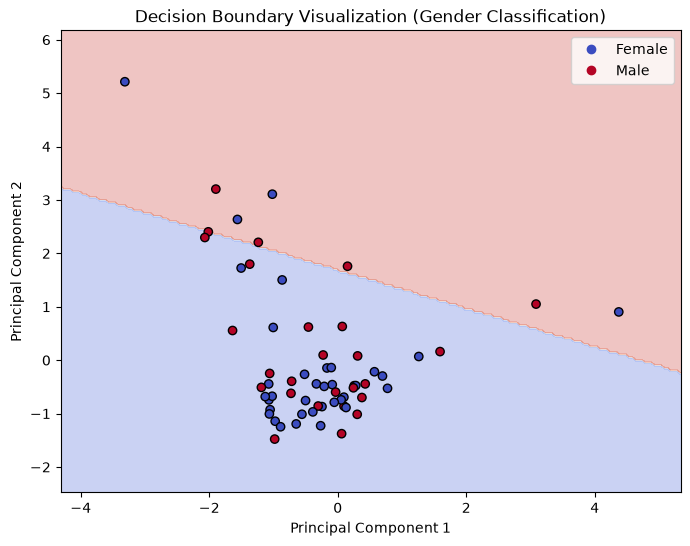

In [17]:
x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))
Z = model_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test_c, edgecolor='k', cmap='coolwarm')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Decision Boundary Visualization (Gender Classification)")
handles, labels = scatter.legend_elements()
plt.legend(handles, ['Female', 'Male'], loc="best")
plt.show()

9. ROC Curve

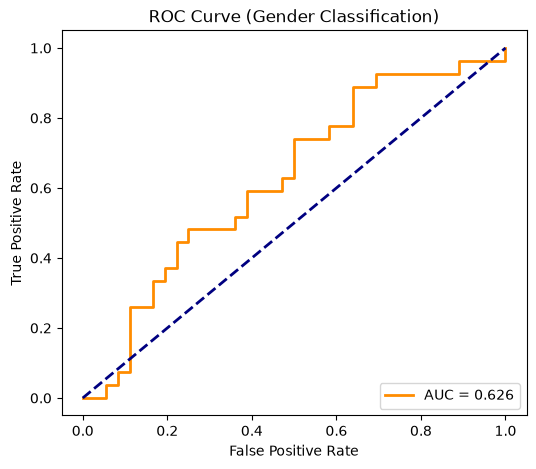

In [18]:
y_prob = model_clf.predict_proba(X_test_pca)[:,1]
fpr, tpr, _ = roc_curve(y_test_c, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Gender Classification)")
plt.legend(loc="lower right")
plt.show()

10. Model Comparison

In [20]:
train_score = model_multiple.score(X_train_m, y_train_m)
test_score = model_multiple.score(X_test_m, y_test_m)
print(f"Training R² Score : {train_score:.3f}")
print(f"Testing R² Score : {test_score:.3f}\n")
summary = pd.DataFrame({
    "Model": ["Simple Regression", "Multiple Regression", "Logistic Regression"],
    "MAE": [round(mae_s,3), round(mae_m,3), "-"],
    "RMSE": [round(rmse_s,3), round(rmse_m,3), "-"],
    "R²": [round(r2_s,3), round(r2_m,3), "-"],
    "Accuracy": ["-", "-", round(acc,3)]
})
display(summary)

Training R² Score : 0.052
Testing R² Score : -0.009



,Model,MAE,RMSE,R²,Accuracy
0,Simple Regression,6.501,8.297,0.003,-
1,Multiple Regression,6.631,8.347,-0.009,-
2,Logistic Regression,-,-,-,0.571
